In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
df=pd.read_csv("tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [78]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [79]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [81]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [82]:
df.duplicated().sum()


np.int64(0)

In [83]:
# let fill null values from age by 

print(df['Age'].skew())

0.4573612871503845


In [84]:
# as skew value is 0.4<0.5 so we prefer median since skew>0.5 or skew<-0.5
# if skew is nearly approx 0 then prefer mean or median


medi=df['Age'].median()
df['Age']=df['Age'].fillna(medi)
df['Age']

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    27.0
414    39.0
415    38.5
416    27.0
417    27.0
Name: Age, Length: 418, dtype: float64

In [85]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [86]:
df['Fare']=df['Fare'].ffill()
df['Fare']

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [87]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

In [88]:
# lot of null values in Cabin column so drop it
df.drop('Cabin',axis=1,inplace=True)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S


In [89]:
df.columns
# now 'Cabin' column is deleted

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [90]:
# By using Random Forest Classifier to find survived or not?

# Survival prediction by Pclass,Sex,Age,Embarked and Family Size(new feature by combining 'SibSp',and  'Parch' and passenger themselves so,+1)

from sklearn.ensemble import RandomForestClassifier

In [127]:
# new feature
df['FamilySize']=df['SibSp']+df['Parch']+1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,1
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,1


In [92]:
from sklearn.preprocessing import LabelEncoder

In [93]:


le_emb=LabelEncoder()
le_sex=LabelEncoder()


df['Embarked']=le_emb.fit_transform(df['Embarked'])
df['Sex']=le_sex.fit_transform(df['Sex'])

x=df[['Sex', 'Age','Embarked','FamilySize']]
y=df['Survived']

model=RandomForestClassifier(n_estimators=10,random_state=100)

model.fit(x,y)

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


In [94]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_pred=model.predict(x)
conf=confusion_matrix(y,y_pred)
print("Confusion matrix:\n ",conf)
acc=accuracy_score(y,y_pred)
print("Accuracy score:",acc)

Confusion matrix:
  [[266   0]
 [  0 152]]
Accuracy score: 1.0


In [99]:
# start prediction for survived or not
name=input("Enter name of the passenger")
sex=input("Enter Gender").strip().lower()
age=int(input("Enter Age"))
embark=input("Enter Embarkment i.e,Cherbourg (C).|Southampton (S)|Queenstown (Q)").strip().upper()
familysize=int(input("Enter total number of member in family"))


# for some safety check
if sex not in le_sex.classes_:
    raise ValueError(f"Invalid Gender given {sex}")
if embark not in le_emb.classes_:
    raise ValueError(f"Invalid Embarkment given :{embark}")

# let transform it into number
sex=le_sex.transform([sex])[0]
embark=le_emb.transform([embark])[0]


# new prediction
prediction=model.predict([[sex,age,embark,familysize]])
print("Predicted Result for Survived or Not :")

if prediction[0]==1: #1 for Survived = Yes
    print("Yes! Passenger is Survived")
else:  #0 for Survived= No
    print("Sorry! Passenger is no more Survived")

Enter name of the passenger Rose Dawson
Enter Gender Female
Enter Age 20
Enter Embarkment i.e,Cherbourg (C).|Southampton (S)|Queenstown (Q) S
Enter total number of member in family 2


Predicted Result for Survived or Not :
Yes! Passenger is Survived


C:\Users\ELCOT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


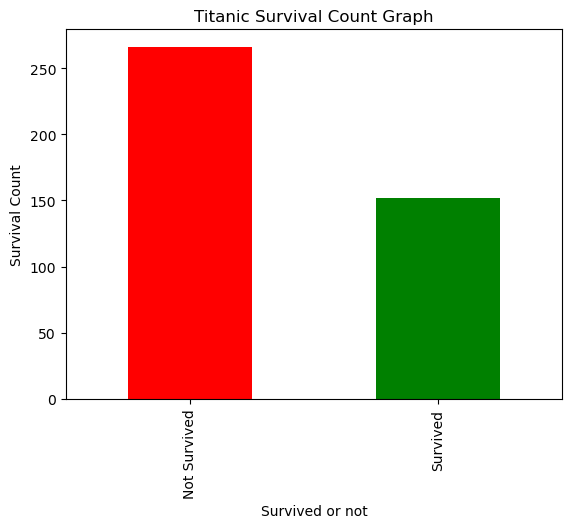

In [107]:
# let plot graph: 
# 1. Survival count
df['Survived'].value_counts().plot(kind="bar",color=['red','green'])

plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.xlabel("Survived or not")
plt.ylabel("Survival Count")
plt.title("Titanic Survival Count Graph")
plt.show()

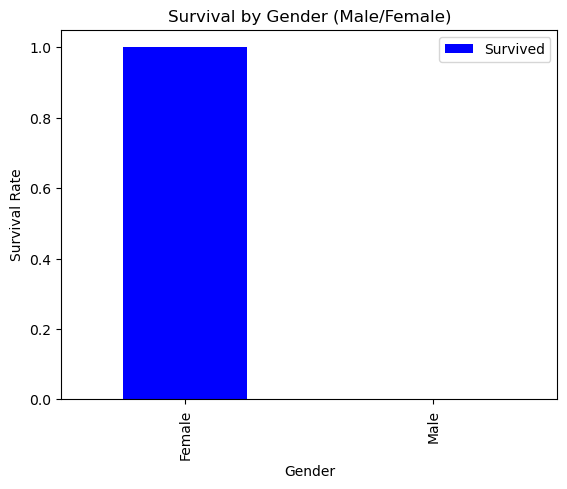

In [118]:
# Survival by Gender

df.groupby('Sex')['Survived'].mean().plot(kind='bar',color=['blue','purple'])
plt.title("Survival by Gender (Male/Female)")
plt.xticks([0,1],["Female","Male"],label=['Female','Male'])
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.legend()
plt.show()



# df.columns

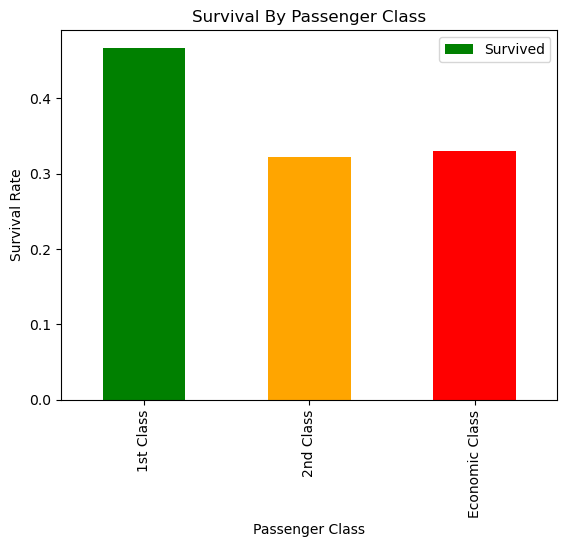

In [126]:
# Survival by Passenger Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',color=['green','orange','red'])
plt.title("Survival By Passenger Class")
plt.xticks([0,1,2],['1st Class','2nd Class','Economic Class'],label=['1st Class','2nd Class','Economic Class'])
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend()
plt.show()


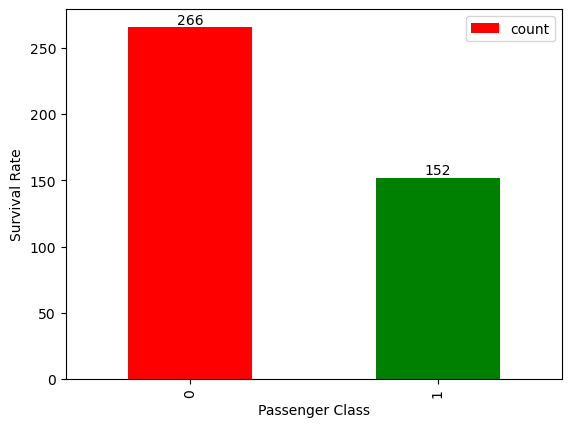

In [136]:
# Survival by Survival By familysize
survived=df.groupby('FamilySize')['Survived'].mean()
# plt.bar(survived.index,survived.values,color="purple")
# plt.xticks([0,1],["FamilySize","Survived"],label=["Family size","Survival Rate"])


counts = df['Survived'].value_counts()
bars = counts.plot(kind="bar", color=["red", "green"])
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

# Add text on bars
for index, value in enumerate(counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.legend()
plt.show()
# df.columns

In [ ]:
# Small families → higher survival chance
# Alone passengers → lower survival
# Very large families → lower survival (panic / difficulty)